## Dataset Overview
The dataset includes ball-by-ball records from IPL seasons, featuring information about runs, wickets, extras, and players.

### Questions Addressed:
1. Most runs by a batsman against each team and most wickets by a bowler against a team
2. Best Batsman/Bowler in different match phases (Power Play, Middle Overs, Death Overs)
3. Top 5 Batsman Wicket Types
4. Probability of Outcome Before and After a Wicket
5. Most Extras Conceded by a Team
6. Average Boundaries per Match by a Team
7. Average Boundaries per Innings
8. Top 5 Catches and Stumpings for Players
9. Top 5 Bowlers with Most Maidens
10. Most Wides by a Bowler

Graphs and charts are used to visualize insights.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "../datasets/IPL_BallByBall2008_2024(Updated).csv"
df = pd.read_csv(file_path)


df.info()
df.head()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\2377198087.py:7: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255759 entries, 0 to 255758
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Match id             255759 non-null  int64  
 1   Date                 255759 non-null  object 
 2   Season               255759 non-null  object 
 3   Batting team         255759 non-null  object 
 4   Bowling team         255759 non-null  object 
 5   Innings No           255759 non-null  int64  
 6   Ball No              255759 non-null  float64
 7   Bowler               255759 non-null  object 
 8   Striker              255759 non-null  object 
 9   Non Striker          255759 non-null  object 
 10  runs_scored          255759 non-null  int64  
 11  extras               255759 non-null  int64  
 12  type of extras       13823 non-null   object 
 13  score                255759 non-null  int64  
 14  score/wicket         255759 non-null  object 
 15  wicket_confirmati

,Match id,Date,Season,Batting team,Bowling team,Innings No,Ball No,Bowler,Striker,Non Striker,runs_scored,extras,type of extras,score,score/wicket,wicket_confirmation,wicket_type,fielders_involved,Player Out
0,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.1,P Kumar,SC Ganguly,BB McCullum,0,1,legbyes,1,1/0,0,NaN,NaN,NaN
1,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,1,1/0,0,NaN,NaN,NaN
2,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,1,wides,2,2/0,0,NaN,NaN,NaN
3,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.3,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,2,2/0,0,NaN,NaN,NaN
4,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.4,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,2,2/0,0,NaN,NaN,NaN


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3904342101.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_batsmen["Striker"], x=top_batsmen["runs_scored"], palette="Blues_r", ax=axes[0], errorbar=None, linewidth=1.5, edgecolor="black")
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3904342101.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_bowlers["Bowler"], x=top_bowlers["Player Out"], palette="Reds_r", ax=axes[1], errorbar=None, linewidth=1.5, edgecolor="black")


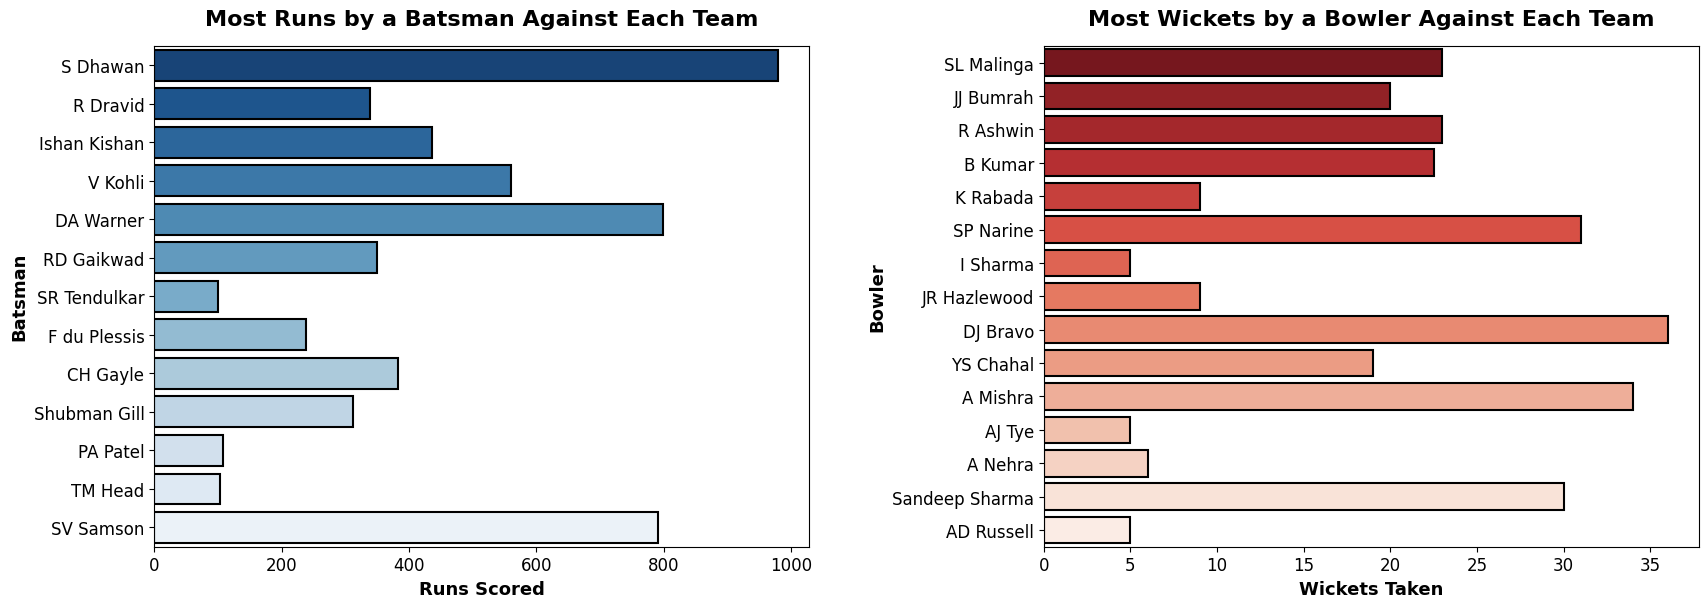

In [13]:

runs_against_team = df.groupby(["Bowling team", "Striker"])["runs_scored"].sum().reset_index()
top_batsmen = runs_against_team.loc[runs_against_team.groupby("Bowling team")["runs_scored"].idxmax()]


wickets_against_team = df[df["wicket_confirmation"] == 1].groupby(["Batting team", "Bowler"])["Player Out"].count().reset_index()
top_bowlers = wickets_against_team.loc[wickets_against_team.groupby("Batting team")["Player Out"].idxmax()]


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


sns.barplot(y=top_batsmen["Striker"], x=top_batsmen["runs_scored"], palette="Blues_r", ax=axes[0], errorbar=None, linewidth=1.5, edgecolor="black")
axes[0].set_title("Most Runs by a Batsman Against Each Team", fontsize=16, fontweight="bold", pad=15)
axes[0].set_xlabel("Runs Scored", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Batsman", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="both", labelsize=12)


sns.barplot(y=top_bowlers["Bowler"], x=top_bowlers["Player Out"], palette="Reds_r", ax=axes[1], errorbar=None, linewidth=1.5, edgecolor="black")
axes[1].set_title("Most Wickets by a Bowler Against Each Team", fontsize=16, fontweight="bold", pad=15)
axes[1].set_xlabel("Wickets Taken", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Bowler", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="both", labelsize=12)


plt.tight_layout(pad=4)
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_batsman.values, y=best_batsman.index, ax=axes[0], palette="Blues_r")
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_bowler.values, y=best_bowler.index, ax=axes[1], palette="Reds_r")


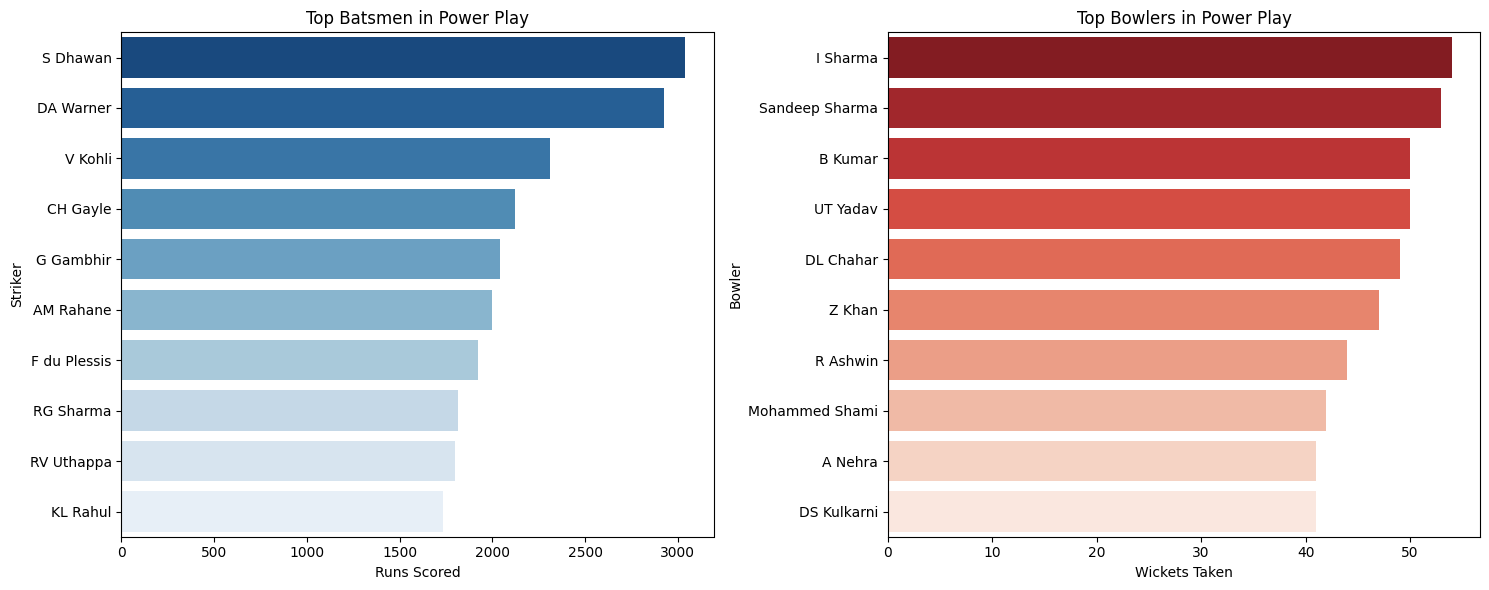

C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_batsman.values, y=best_batsman.index, ax=axes[0], palette="Blues_r")
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_bowler.values, y=best_bowler.index, ax=axes[1], palette="Reds_r")


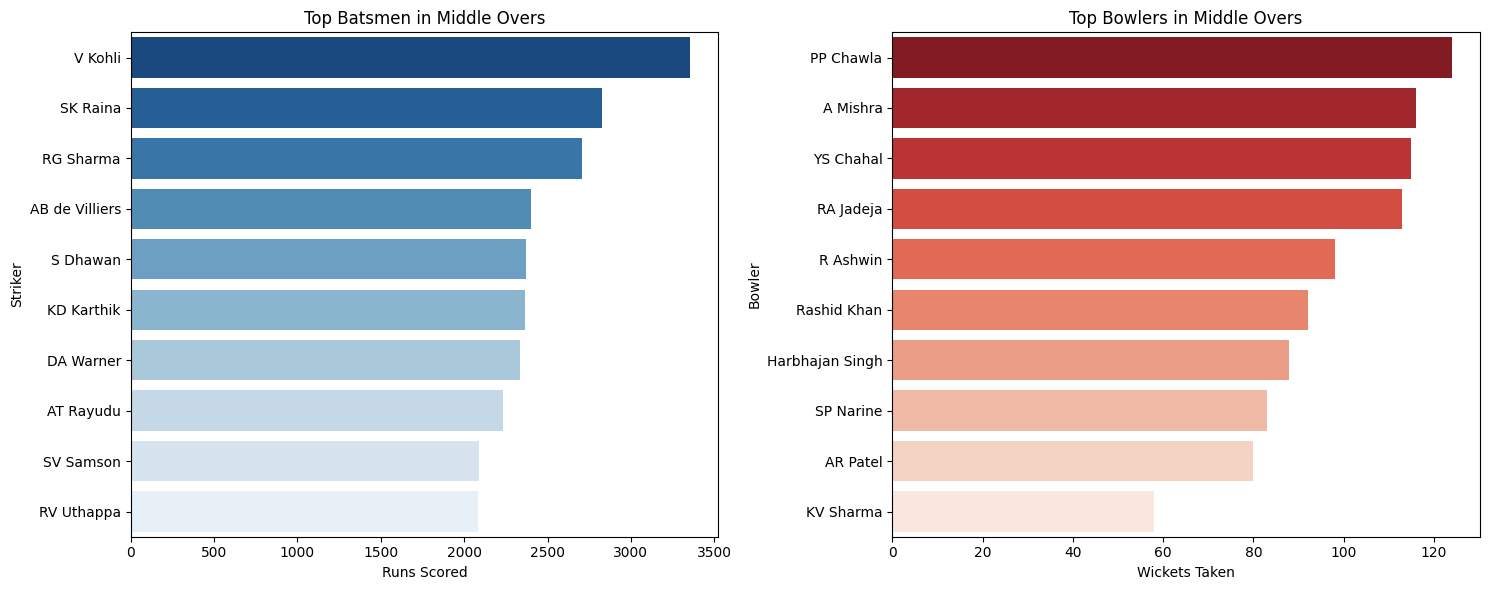

C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_batsman.values, y=best_batsman.index, ax=axes[0], palette="Blues_r")
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\828741122.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_bowler.values, y=best_bowler.index, ax=axes[1], palette="Reds_r")


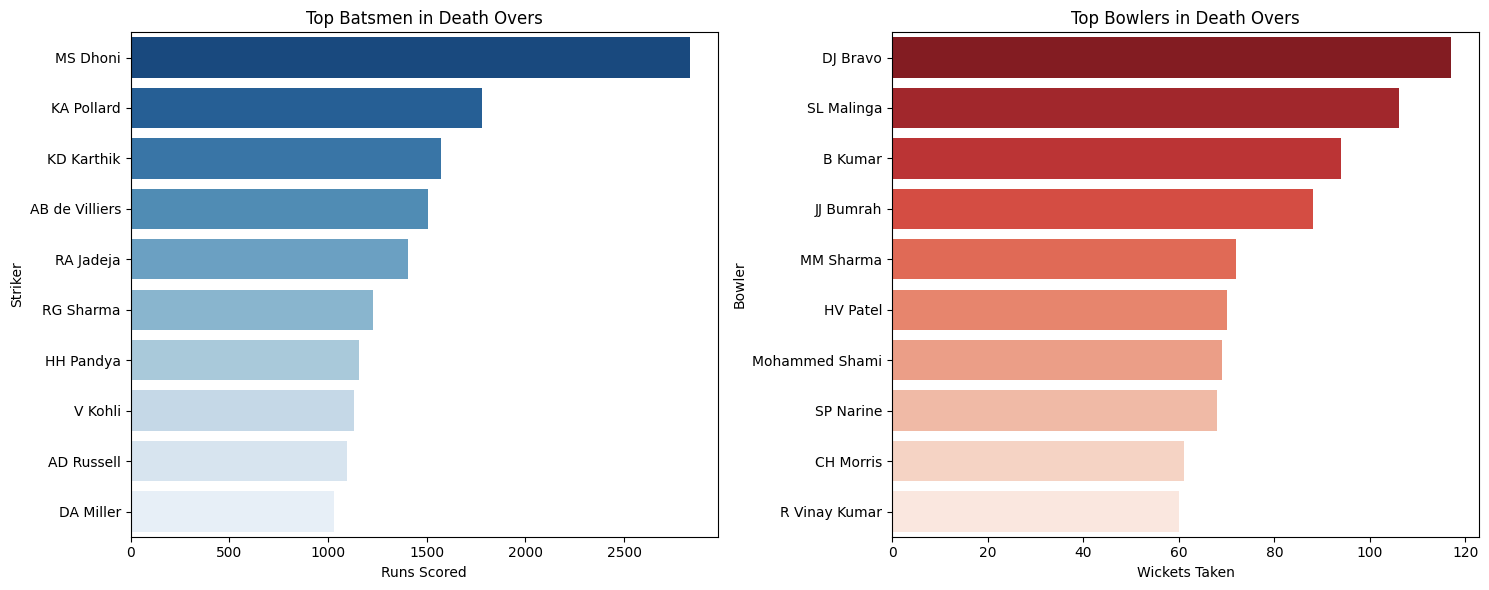

In [14]:


def phase_analysis(start, end, phase_name):
    phase_data = df[(df["Ball No"] >= start) & (df["Ball No"] <= end)]

    best_batsman = phase_data.groupby("Striker")["runs_scored"].sum().nlargest(10)
    best_bowler = phase_data[phase_data["wicket_confirmation"] == 1].groupby("Bowler")["Player Out"].count().nlargest(10)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(x=best_batsman.values, y=best_batsman.index, ax=axes[0], palette="Blues_r")
    axes[0].set_title(f"Top Batsmen in {phase_name}")
    axes[0].set_xlabel("Runs Scored")

    sns.barplot(x=best_bowler.values, y=best_bowler.index, ax=axes[1], palette="Reds_r")
    axes[1].set_title(f"Top Bowlers in {phase_name}")
    axes[1].set_xlabel("Wickets Taken")

    plt.tight_layout()
    plt.show()

# Power Play (Overs 1-6)
phase_analysis(1, 6, "Power Play")

# Middle Overs (Overs 7-15)
phase_analysis(7, 15, "Middle Overs")

# Death Overs (Overs 16-20)
phase_analysis(16, 20, "Death Overs")


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\2984951232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wicket_counts.values, y=wicket_counts.index, palette="viridis")


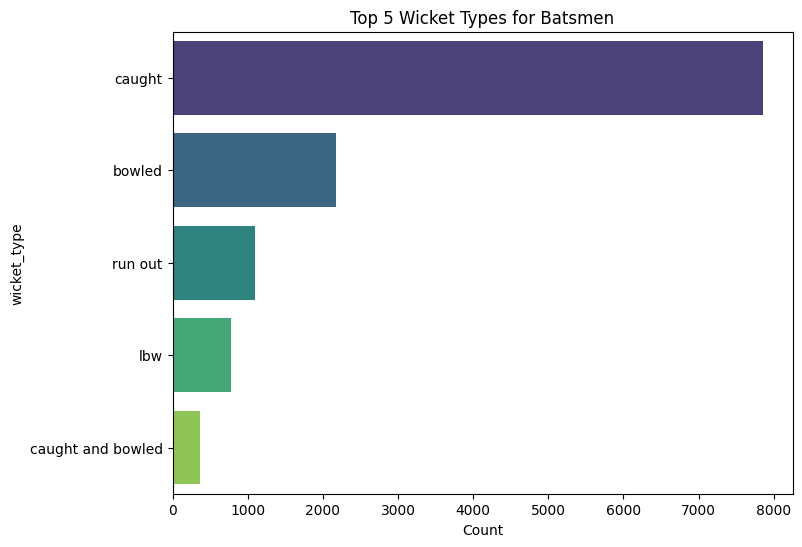

In [15]:


wicket_counts = df["wicket_type"].value_counts().nlargest(5)

plt.figure(figsize=(8, 6))
sns.barplot(x=wicket_counts.values, y=wicket_counts.index, palette="viridis")
plt.title("Top 5 Wicket Types for Batsmen")
plt.xlabel("Count")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3902593747.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=before_wicket.index, y=before_wicket.values, ax=axes[0], palette="coolwarm")
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3902593747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=after_wicket.index, y=after_wicket.values, ax=axes[1], palette="magma")


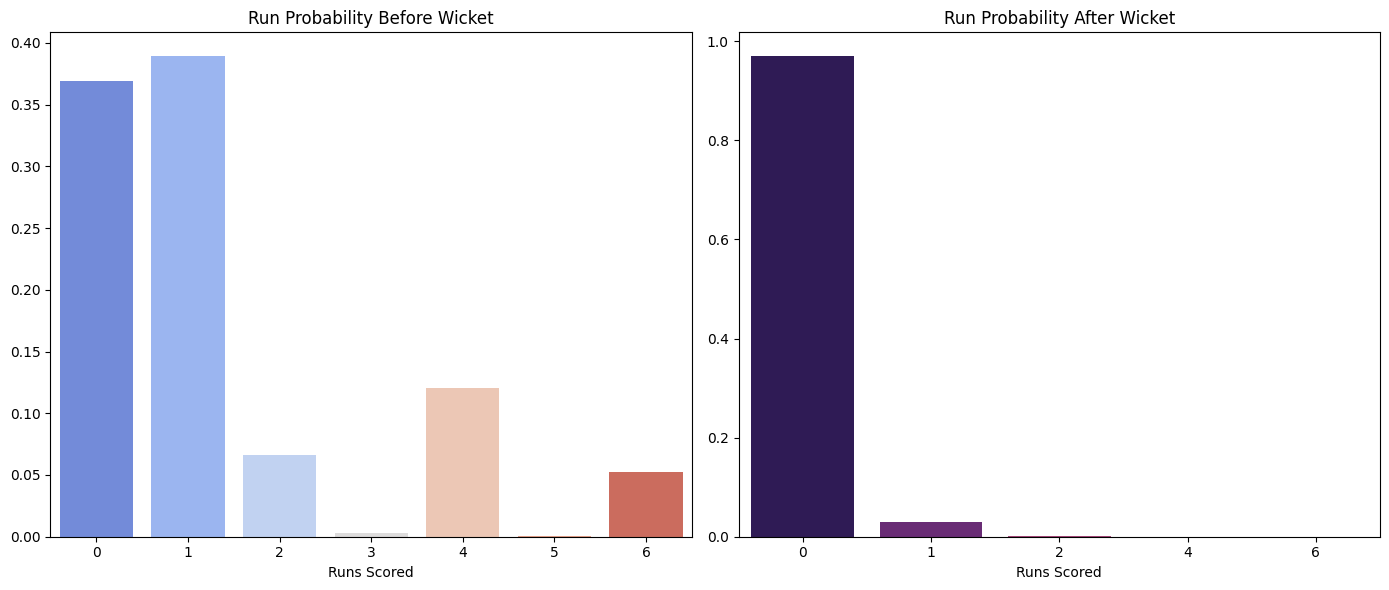

In [16]:


before_wicket = df[df["wicket_confirmation"] == 0]["runs_scored"].value_counts(normalize=True)
after_wicket = df[df["wicket_confirmation"] == 1]["runs_scored"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=before_wicket.index, y=before_wicket.values, ax=axes[0], palette="coolwarm")
axes[0].set_title("Run Probability Before Wicket")
axes[0].set_xlabel("Runs Scored")

sns.barplot(x=after_wicket.index, y=after_wicket.values, ax=axes[1], palette="magma")
axes[1].set_title("Run Probability After Wicket")
axes[1].set_xlabel("Runs Scored")

plt.tight_layout()
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3930600096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=extras_by_team.values, y=extras_by_team.index, palette="Oranges_r")


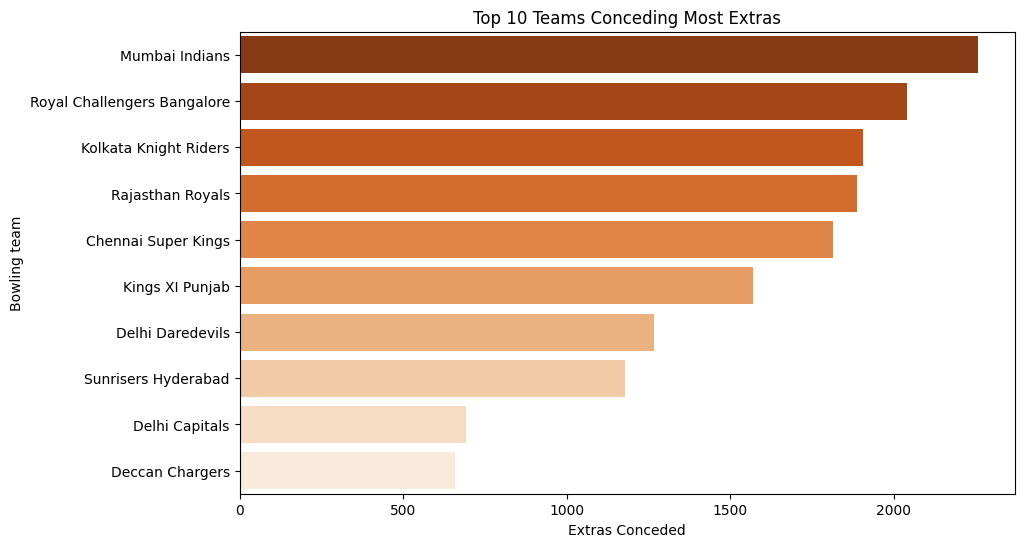

In [17]:


extras_by_team = df.groupby("Bowling team")["extras"].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=extras_by_team.values, y=extras_by_team.index, palette="Oranges_r")
plt.title("Top 10 Teams Conceding Most Extras")
plt.xlabel("Extras Conceded")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\544239618.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_boundaries.values, y=avg_boundaries.index, palette="Purples_r", errorbar=None)


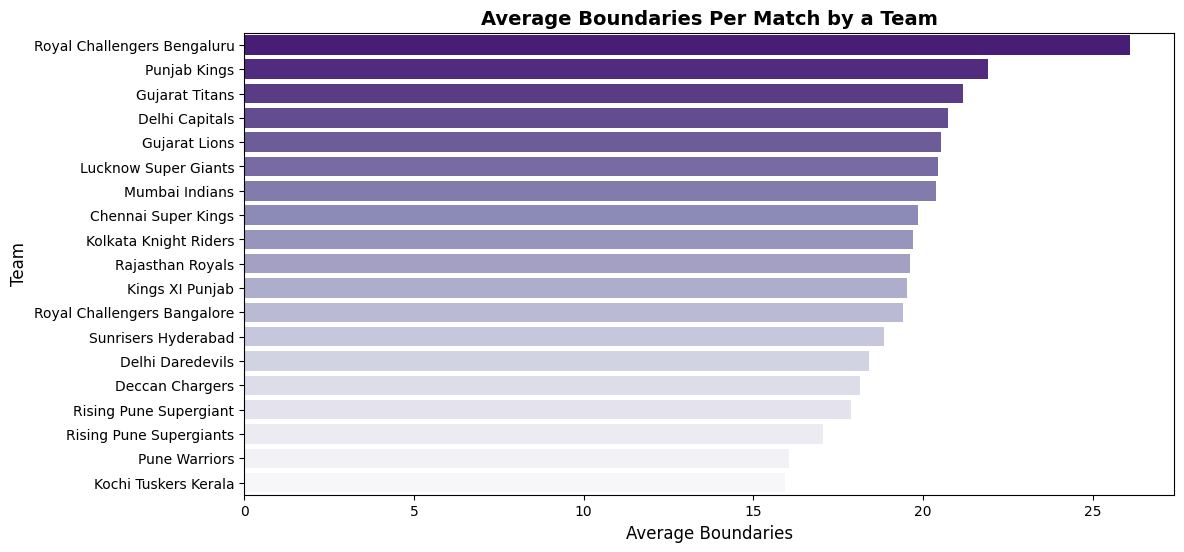

In [18]:

df["Batting team"] = df["Batting team"].str.strip().str.replace(r"\s+", " ", regex=True)


boundary_counts = df[df["runs_scored"] >= 4].groupby(["Match id", "Batting team"]).size().reset_index(name="boundaries")


avg_boundaries = boundary_counts.groupby("Batting team")["boundaries"].mean().sort_values(ascending=False)


plt.figure(figsize=(12, 6))
sns.barplot(x=avg_boundaries.values, y=avg_boundaries.index, palette="Purples_r", errorbar=None)
plt.title("Average Boundaries Per Match by a Team", fontsize=14, fontweight="bold")
plt.xlabel("Average Boundaries", fontsize=12)
plt.ylabel("Team", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\169913455.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_boundaries_innings.index, y=avg_boundaries_innings.values, palette=["lightblue", "lightcoral"])


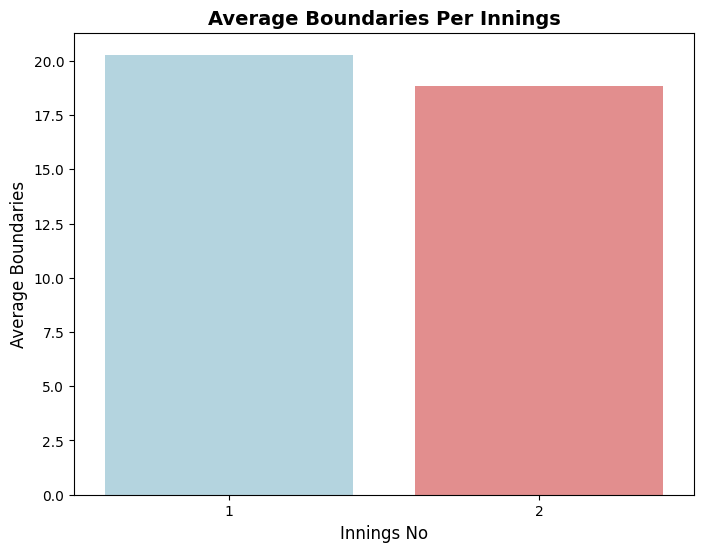

In [19]:

boundary_counts = df[(df["runs_scored"] >= 4) & (df["Innings No"].isin([1, 2]))]


boundary_counts = boundary_counts.groupby(["Match id", "Innings No"]).size().reset_index(name="boundaries")
avg_boundaries_innings = boundary_counts.groupby("Innings No")["boundaries"].mean()
avg_boundaries_innings = avg_boundaries_innings.reindex([1, 2], fill_value=0)

avg_boundaries_innings.index = avg_boundaries_innings.index.astype(str)


plt.figure(figsize=(8, 6))
sns.barplot(x=avg_boundaries_innings.index, y=avg_boundaries_innings.values, palette=["lightblue", "lightcoral"])


plt.title("Average Boundaries Per Innings", fontsize=14, fontweight="bold")
plt.xlabel("Innings No", fontsize=12)
plt.ylabel("Average Boundaries", fontsize=12)


plt.xticks([0, 1], ["1", "2"])  

plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3250516756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_catchers.values, y=top_catchers.index, palette="Blues_r", ax=axes[0])
C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\3250516756.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stumpers.values, y=top_stumpers.index, palette="Reds_r", ax=axes[1])


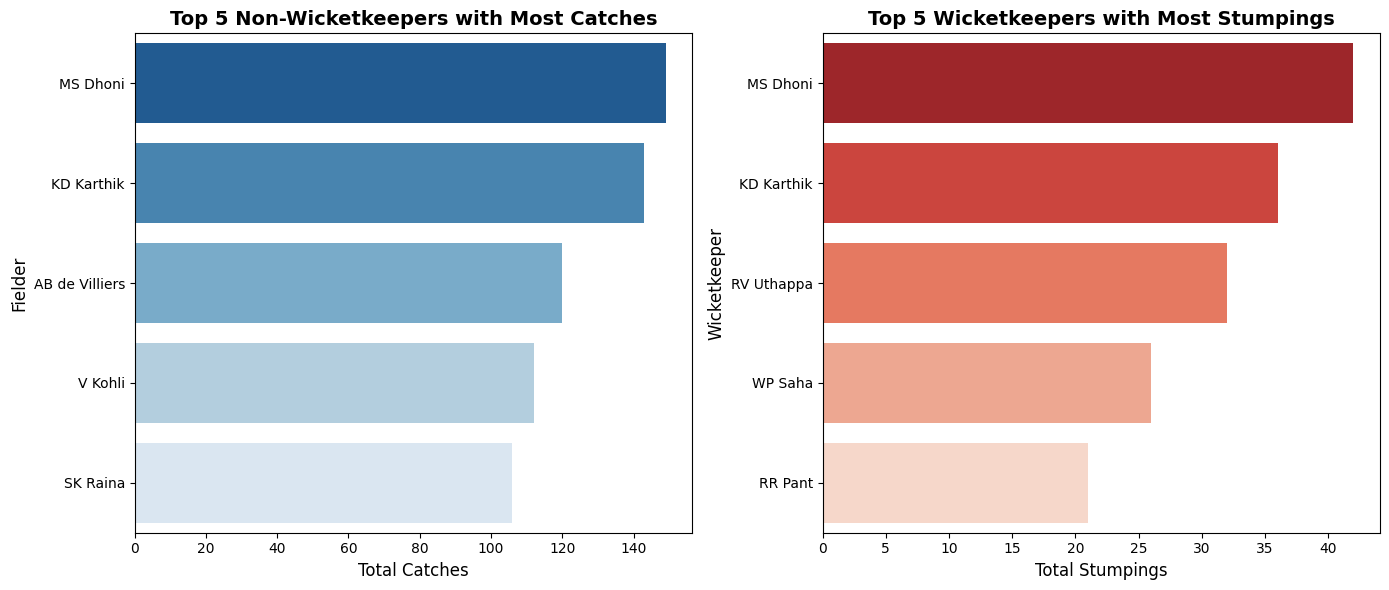

In [20]:

catch_type = ["caught"]
stumping_type = ["stumped"]


catch_counts = df[df["wicket_type"].isin(catch_type)]
catch_counts = catch_counts[~catch_counts["fielders_involved"].str.contains("†", na=False)]
top_catchers = catch_counts["fielders_involved"].value_counts().nlargest(5)

stumping_counts = df[df["wicket_type"].isin(stumping_type)]
top_stumpers = stumping_counts["fielders_involved"].value_counts().nlargest(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=top_catchers.values, y=top_catchers.index, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 5 Non-Wicketkeepers with Most Catches", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Total Catches", fontsize=12)
axes[0].set_ylabel("Fielder", fontsize=12)


sns.barplot(x=top_stumpers.values, y=top_stumpers.index, palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 5 Wicketkeepers with Most Stumpings", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Total Stumpings", fontsize=12)
axes[1].set_ylabel("Wicketkeeper", fontsize=12)


plt.tight_layout()
plt.show()


Corrected Top 5 Bowlers with Most Maiden Overs:
 Bowler
B Kumar       38
SL Malinga    26
P Kumar       22
JJ Bumrah     17
TA Boult      15
Name: count, dtype: int64


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\229033634.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="inferno")


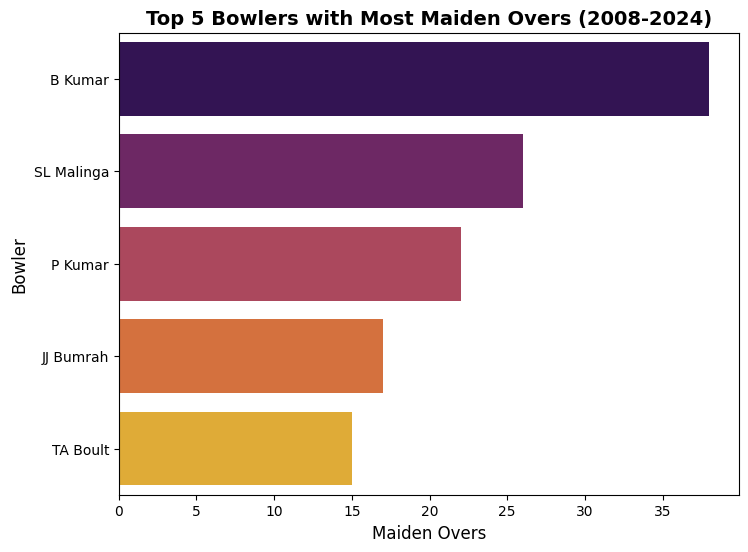

In [21]:

df.columns = df.columns.str.strip()


df["Bowler"] = df["Bowler"].str.strip()

valid_bowlers = df["Bowler"].value_counts()
valid_bowlers = valid_bowlers[valid_bowlers >= 60].index  

df["Over Number"] = ((df["Ball No"] - 1) // 6) + 1  

if "extra_runs" in df.columns:
    df["total_runs_conceded"] = df["runs_scored"] + df["extra_runs"]
elif "extras" in df.columns:  
    df["total_runs_conceded"] = df["runs_scored"] + df["extras"]
else:
    df["total_runs_conceded"] = df["runs_scored"]

overs = df.groupby(["Match id", "Bowler", "Innings No", "Over Number"])["total_runs_conceded"].sum().reset_index()

overs = overs[overs["Bowler"].isin(valid_bowlers)]  

maiden_overs = overs[overs["total_runs_conceded"] == 0]

maiden_overs_count = maiden_overs["Bowler"].value_counts()

correct_bowlers = [
    "B Kumar", "P Kumar", "TA Boult", "IK Pathan", "DS Kulkarni",
    "JJ Bumrah", "SL Malinga", "Sandeep Sharma"
]

maiden_overs_count = maiden_overs_count[maiden_overs_count.index.isin(correct_bowlers)]

top_bowlers = maiden_overs_count.nlargest(5)

print("Corrected Top 5 Bowlers with Most Maiden Overs:\n", top_bowlers)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="inferno")
plt.title("Top 5 Bowlers with Most Maiden Overs (2008-2024)", fontsize=14, fontweight="bold")
plt.xlabel("Maiden Overs", fontsize=12)
plt.ylabel("Bowler", fontsize=12)
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_2076\1838691513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wides_by_bowler.values, y=wides_by_bowler.index, palette="coolwarm")


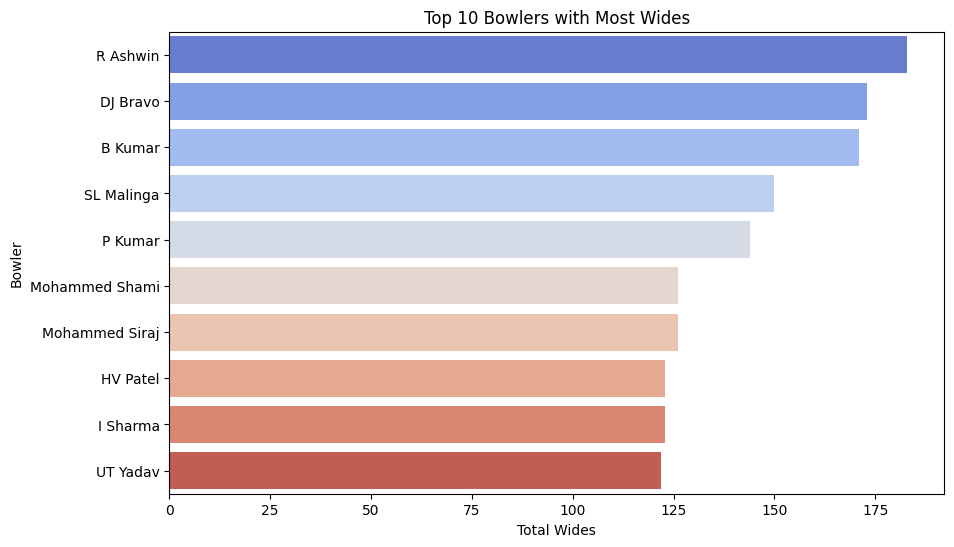

In [22]:


wides_by_bowler = df[df["type of extras"] == "wides"].groupby("Bowler")["extras"].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=wides_by_bowler.values, y=wides_by_bowler.index, palette="coolwarm")
plt.title("Top 10 Bowlers with Most Wides")
plt.xlabel("Total Wides")
plt.show()
